# Рубежный контроль №1

**Тема:** Технологии разведочного анализа и обработки данных.

**Студент:** Варданян Давид Артурович

**Группа:** ИУ5-64Б

**Вариант:** 4 — Задача №1, набор данных №4 ([Heart Disease Dataset](https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset)).

**Доп. требование группы ИУ5-64Б:** скрипичная диаграмма (violin plot).

## Постановка задачи

Для набора данных Heart Disease провести корреляционный анализ. При наличии пропусков — удалить соответствующие строки или колонки. Сделать выводы о возможности построения моделей машинного обучения и о вкладе признаков.

## Импорт библиотек

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)
rng = np.random.default_rng(42)

## Загрузка данных

Файл `data/heart.csv` (1025 наблюдений, 14 признаков). Целевой признак — `target` (наличие сердечного заболевания: 0/1).

In [2]:
df = pd.read_csv('data/heart.csv')
df.shape

(1025, 14)

## Первичный осмотр

In [3]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [4]:
df.dtypes

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

In [5]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


## Искусственные пропуски

В исходном наборе пропусков нет, поэтому, согласно примечанию к заданию, вносим NaN в две колонки (`chol`, `thalach`) — примерно 5% значений в каждой.

In [6]:
df_na = df.copy()
for col in ['chol', 'thalach']:
    idx = rng.choice(df_na.index, size=int(len(df_na) * 0.05), replace=False)
    df_na.loc[idx, col] = np.nan
df_na.isna().sum()

age          0
sex          0
cp           0
trestbps     0
chol        51
fbs          0
restecg      0
thalach     51
exang        0
oldpeak      0
slope        0
ca           0
thal         0
target       0
dtype: int64

## Обработка пропусков

Удаляем строки с NaN (`dropna`) — потеря объёма выборки невелика.

In [7]:
df_clean = df_na.dropna().reset_index(drop=True)
print('До:', df_na.shape)
print('После:', df_clean.shape)

До: (1025, 14)
После: (928, 14)


## Корреляционный анализ

Считаем матрицу корреляций Пирсона и строим тепловую карту.

In [8]:
corr = df_clean.corr(numeric_only=True)
corr

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.110236,-0.066978,0.269321,0.216888,0.110955,-0.122713,-0.383316,0.078036,0.208413,-0.176131,0.252310,0.065425,-0.219730
sex,-0.110236,1.000000,-0.044306,-0.081236,-0.199769,0.030588,-0.048382,-0.048344,0.143128,0.077402,-0.039579,0.122111,0.206061,-0.284296
cp,-0.066978,-0.044306,1.000000,0.059810,-0.082897,0.060549,0.040862,0.326574,-0.391846,-0.176843,0.142653,-0.175615,-0.151265,0.437880
trestbps,0.269321,-0.081236,0.059810,1.000000,0.140658,0.180341,-0.106364,-0.029906,0.028440,0.186033,-0.097388,0.093452,0.054686,-0.117255
chol,0.216888,-0.199769,-0.082897,0.140658,1.000000,0.018227,-0.147366,-0.020988,0.055549,0.085942,-0.021027,0.065145,0.092878,-0.093700
fbs,0.110955,0.030588,0.060549,0.180341,0.018227,1.000000,-0.105545,-0.022706,0.064620,0.022178,-0.070283,0.138945,-0.043230,-0.062210
restecg,-0.122713,-0.048382,0.040862,-0.106364,-0.147366,-0.105545,1.000000,0.048051,-0.058454,-0.036527,0.078032,-0.063535,-0.024055,0.130646
thalach,-0.383316,-0.048344,0.326574,-0.029906,-0.020988,-0.022706,0.048051,1.000000,-0.389132,-0.349757,0.385384,-0.200351,-0.091757,0.420906
exang,0.078036,0.143128,-0.391846,0.028440,0.055549,0.064620,-0.058454,-0.389132,1.000000,0.306998,-0.266943,0.096675,0.183252,-0.431137
oldpeak,0.208413,0.077402,-0.176843,0.186033,0.085942,0.022178,-0.036527,-0.349757,0.306998,1.000000,-0.581718,0.213090,0.195119,-0.436094


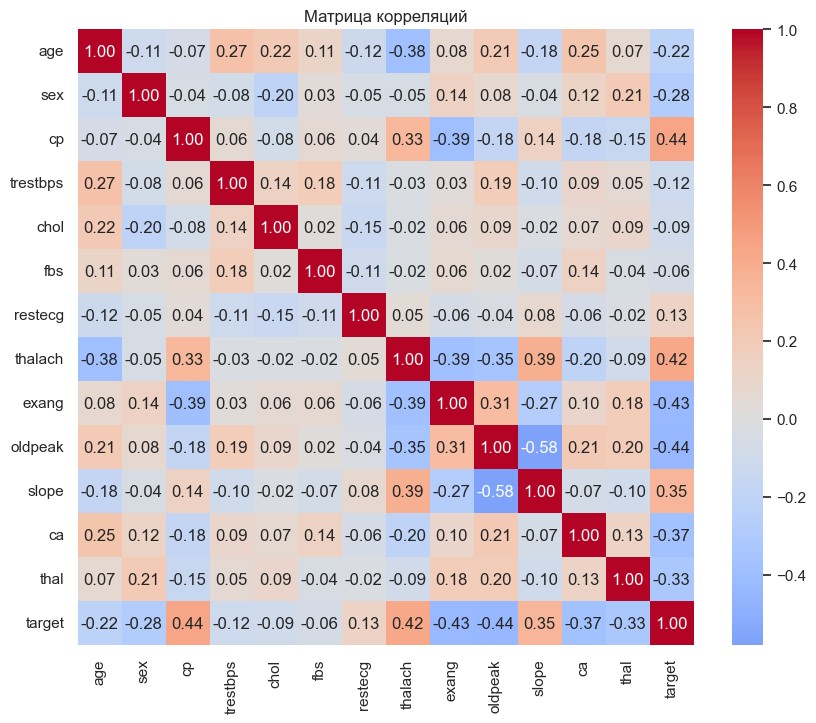

In [9]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, ax=ax)
ax.set_title('Матрица корреляций')
plt.show()

Корреляции каждого признака с целевой переменной `target`, отсортированные по модулю.

In [10]:
target_corr = corr['target'].drop('target').sort_values(key=np.abs, ascending=False)
target_corr

cp          0.437880
oldpeak    -0.436094
exang      -0.431137
thalach     0.420906
ca         -0.374762
slope       0.348219
thal       -0.327990
sex        -0.284296
age        -0.219730
restecg     0.130646
trestbps   -0.117255
chol       -0.093700
fbs        -0.062210
Name: target, dtype: float64

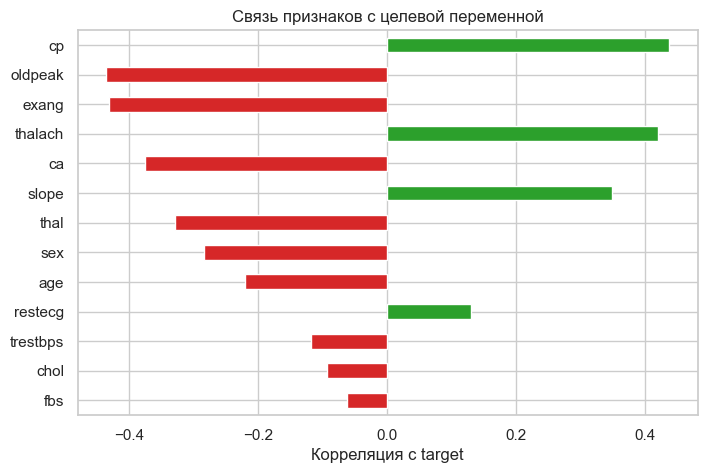

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
target_corr.plot(kind='barh', color=['#d62728' if v < 0 else '#2ca02c' for v in target_corr], ax=ax)
ax.set_xlabel('Корреляция с target')
ax.set_title('Связь признаков с целевой переменной')
ax.invert_yaxis()
plt.show()

## Скрипичная диаграмма (violin plot)

Доп. требование группы ИУ5-64Б. Распределение `thalach` (макс. ЧСС) в разрезе целевой переменной.

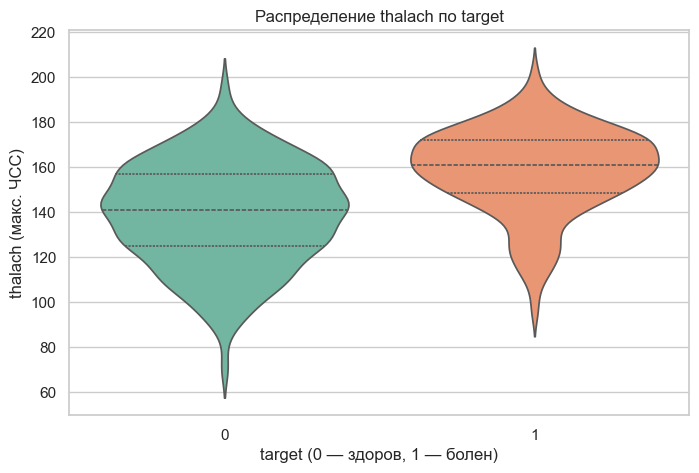

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.violinplot(data=df_clean, x='target', y='thalach', hue='target',
               palette='Set2', inner='quartile', legend=False, ax=ax)
ax.set_xlabel('target (0 — здоров, 1 — болен)')
ax.set_ylabel('thalach (макс. ЧСС)')
ax.set_title('Распределение thalach по target')
plt.show()

## Выводы

1. **Качество данных.** В исходном наборе пропусков нет, поэтому они были созданы искусственно (по 5% значений в `chol` и `thalach`). После `dropna` остаётся почти весь объём — выборка достаточна для построения базовых классификационных моделей (логистическая регрессия, случайный лес, k-NN).

2. **Дубликаты.** Версия датасета с Kaggle содержит большое число повторяющихся строк (~700 из 1025). Для реального обучения модели их следовало бы удалить через `drop_duplicates`, иначе одинаковые наблюдения попадут и в train, и в test, что завысит метрики.

3. **Корреляции между признаками.** Сильных межпризнаковых корреляций (|r| > 0.7), способных вызвать выраженную мультиколлинеарность, не наблюдается. Заметнее всего связаны `slope` ↔ `oldpeak` и `cp` ↔ `exang`.

4. **Вклад признаков в целевую переменную.** Наиболее информативны `cp` (тип боли в груди), `thalach` (макс. ЧСС), `exang` (стенокардия при нагрузке), `oldpeak`, `ca` и `slope`. Слабую связь с `target` показывают `fbs`, `chol`, `trestbps` — их можно рассмотреть как кандидатов на исключение или дальнейший feature engineering.

5. **Скрипичная диаграмма** наглядно показывает, что у больных пациентов (`target=1`) распределение `thalach` смещено в сторону больших значений — это согласуется с положительной корреляцией признака с целевой переменной.